In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys
sys.path.insert(0, "../")

from pathlib import Path
import json

import pandas as pd
import seaborn as sns
import numpy as np

from matplotlib.ticker import LogFormatterMathtext


import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    "font.size": 14,          # default font size
    "axes.titlesize": 16,     # title
    "axes.labelsize": 15,     # x/y labels
    "xtick.labelsize": 13,    # x tick labels
    "ytick.labelsize": 13,    # y tick labels
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
})

## Switch between motif length and series-length experiments

In [2]:
max_memory = "8 GB"
# experiment = "motif length"
experiment = "series-length"

## Load data

In [3]:
# Noise relative to the amplitude of the sine wave
amplitude = 5.0

result_dir = Path("../tests/results/synthetic_scampi")

summary_path = result_dir / f"{experiment.replace(" ", "-")}_summary.csv"
jsonl_path = result_dir / f"{experiment.replace(" ", "-")}_runs.jsonl"

summary = pd.read_csv(summary_path)

with jsonl_path.open() as f:
  runs = [json.loads(line) for line in f]

# display(summary.head())

# Basic overview
summary[
  [
      "experiment",
      "n",
      "motif length",
      "noise",
      "seed",
      "scampi_delta",
      "scampi_max_memory",
      "time in s",
      "memory in MB",
      "selected extent",
      "ground truth extent",
      "precision",
      "recall",
      "f_score",
  ]
].head()


# Aggregate runtime and quality over seeds
x_col = "n" if experiment == "series-length" else "motif length"
summary = summary[summary["scampi_max_memory"] == max_memory].copy()

if experiment == "series-length":
    summary = summary[summary["motif length"] == 2048].copy()


agg = (
  summary
  .groupby([x_col, "noise"], as_index=False)
  .agg(
      time_mean=("time in s", "mean"),
      time_std=("time in s", "std"),
      f_score_mean=("f_score", "mean"),
      precision_mean=("precision", "mean"),
      recall_mean=("recall", "mean"),
      extent_mean=("selected extent", "mean"),
      ground_truth_extent=("ground truth extent", "mean"),      
  )
)


# Express noise relative to the motif amplitude
agg["relative_noise"] = agg["noise"] / amplitude
agg["relative_noise_pct"] = 100 * agg["relative_noise"]
agg["relative_noise_label"] = agg["relative_noise_pct"].map(
    lambda value: f"{value:g}%"
)

threshold = 1e-2
agg["relative_extent"] = np.where(
    (agg["extent_mean"] < threshold) &
    (agg["ground_truth_extent"] < threshold),
    1.0,
    np.minimum(agg["extent_mean"] / agg["ground_truth_extent"], 1.0),
)
agg.head()

,n,noise,time_mean,time_std,f_score_mean,precision_mean,recall_mean,extent_mean,ground_truth_extent,relative_noise,relative_noise_pct,relative_noise_label,relative_extent
0,50000,0.00,0.390704,0.507512,1.0,1.0,1.0,6.907324e-08,5.630463e-07,0.00,0.0,0%,1.000000
1,50000,0.05,0.121048,0.001762,1.0,1.0,1.0,8.756194e-01,8.756192e-01,0.01,1.0,1%,1.000000
2,50000,0.10,0.218276,0.018334,1.0,1.0,1.0,3.461736e+00,3.500497e+00,0.02,2.0,2%,0.988927
3,50000,0.20,0.270968,0.104126,1.0,1.0,1.0,1.363357e+01,1.397102e+01,0.04,4.0,4%,0.975847
4,50000,0.25,0.504874,0.314893,1.0,1.0,1.0,2.122955e+01,2.179346e+01,0.05,5.0,5%,0.974125


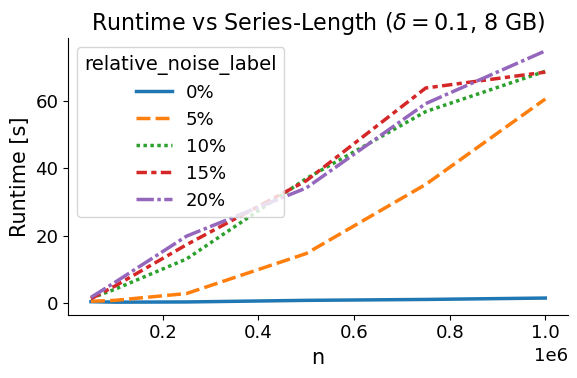

In [4]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(6, 4))

sns.lineplot(
    data=plot_df.sort_values(x_col),
    x=x_col,
    y="time_mean",
    hue="relative_noise_label",
    style="relative_noise_label",
    linewidth=2.5,    
    ax=ax,
)

sns.despine()

ax.set_xlabel(x_col)
ax.set_ylabel("Runtime [s]")
ax.set_title(rf"Runtime vs {experiment.title() } ($\delta=0.1$, {max_memory})")

plt.tight_layout()
plt.savefig(
    f"images/synthetic_runtime_lineplot_{experiment.replace(" ","-")}.pdf",
    bbox_inches="tight",
)
plt.show()

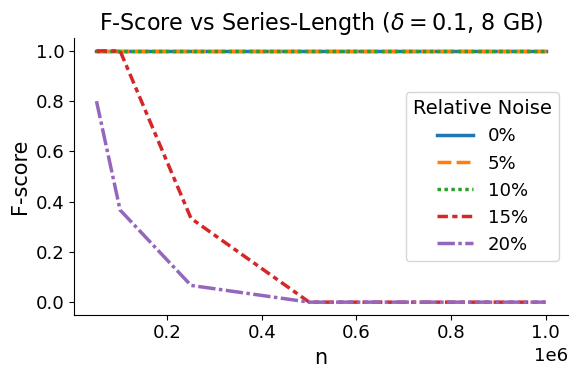

In [5]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(6, 4))

sns.lineplot(
    data=plot_df,
    x=x_col,
    y="f_score_mean",
    hue="relative_noise_label",
    style="relative_noise_label",
    linewidth=2.5, 
    ax=ax,
)


sns.despine()

#ax.set_xscale("log")
#ax.xaxis.set_major_formatter(LogFormatterMathtext())


ax.set_xlabel(x_col)
ax.set_ylabel("F-score")
ax.set_title(rf"F-Score vs {experiment.title() } ($\delta=0.1$, {max_memory})")
ax.legend(title="Relative Noise")
plt.tight_layout()
plt.savefig(
    f"images/synthetic_quality_lineplot_{experiment.replace(" ","-")}.pdf",
    bbox_inches="tight",
)
plt.show()

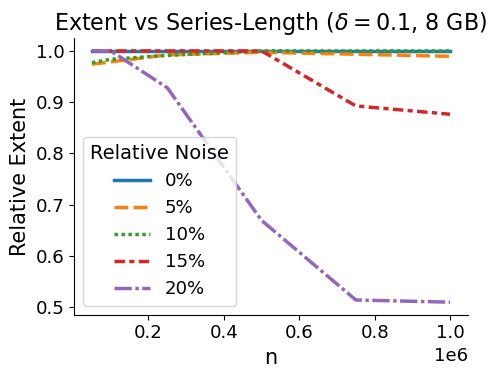

In [6]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(5, 4))

sns.lineplot(
    data=plot_df,
    x=x_col,
    y="relative_extent",
    hue="relative_noise_label",
    style="relative_noise_label",
    linewidth=2.5, 
    ax=ax,
)


sns.despine()

#ax.set_xscale("log")
# ax.xaxis.set_major_formatter(LogFormatterMathtext())
    
ax.set_xlabel(x_col)
ax.set_ylabel("Relative Extent")
ax.set_title(rf"Extent vs {experiment.title() } ($\delta=0.1$, {max_memory})")
ax.legend(title="Relative Noise")
plt.tight_layout()
plt.savefig(
    f"images/synthetic_quality2_lineplot_{experiment.replace(' ', '-')}.pdf",
    bbox_inches="tight",
)
plt.show()

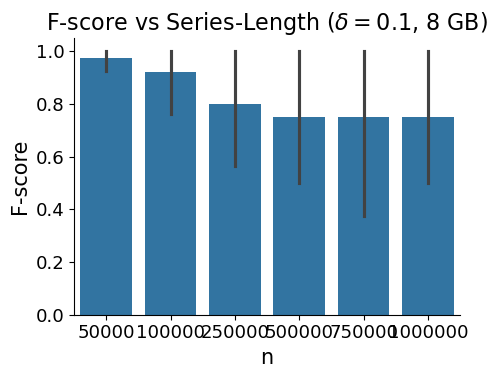

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(
    data=agg,
    x=x_col,
    y="f_score_mean",
    # hue="relative_noise_label",
    legend=False,
    ax=ax,
)

sns.despine()

ax.set_xlabel(x_col)
ax.set_ylabel("F-score")
ax.set_title(rf"F-score vs {experiment.title() } ($\delta=0.1$, {max_memory})")

plt.tight_layout()
plt.savefig(
    f"images/synthetic_quality_length_barplot_{experiment.replace(" ","-")}.pdf",
    bbox_inches="tight",
)
plt.show()

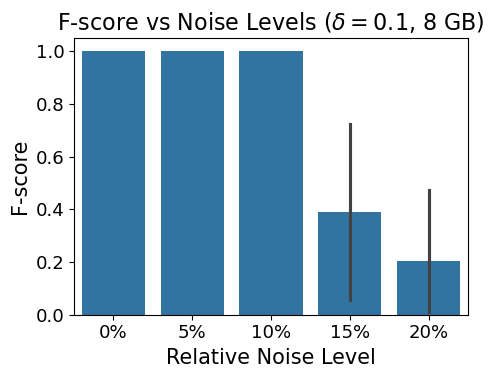

In [8]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(
    data=plot_df,
    x="relative_noise_label",
    y="f_score_mean",
    #hue="relative_noise_label",
    ax=ax,
)

ax.set_xlabel("Relative Noise Level")
ax.set_ylabel("F-score")
ax.set_title(rf"F-score vs Noise Levels ($\delta=0.1$, {max_memory})")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    f"images/synthetic_quality_noise_barplot_{experiment.replace(" ","-")}.pdf",
    bbox_inches="tight",
)
plt.show()

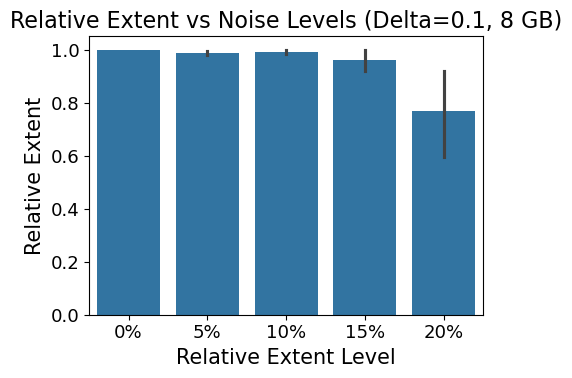

In [9]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(
    data=plot_df,
    x="relative_noise_label",
    y="relative_extent",
    #hue="relative_noise_label",
    ax=ax,
)

ax.set_xlabel("Relative Extent Level")
ax.set_ylabel("Relative Extent")
ax.set_title(f"Relative Extent vs Noise Levels (Delta=0.1, {max_memory})")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    f"images/synthetic_extent_noise_barplot_{experiment.replace(" ","-")}.pdf",
    bbox_inches="tight",
)
plt.show()